In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

# Cargar dataset real de Leonali
df = pd.read_parquet(r'C:\Users\Said\Documents\Datasets\Alimentos\Dataset1_anonimizado.parquet')

# Ver qué canales tenemos disponibles
print(f"Shape: {df.shape}")
print(f"\nCanal1 — valores únicos:\n{df['Canal1'].value_counts()}")
print(f"\nCanal2 — valores únicos:\n{df['Canal2'].value_counts()}")

Shape: (581306, 15)

Canal1 — valores únicos:
Canal1
Autoservicio        473724
Club de Precios      38446
Otros                37452
Food Service         17869
Conveniencia         12918
Mercados               706
Maquinas Vending       191
Name: count, dtype: int64

Canal2 — valores únicos:
Canal2
Walmart      170899
Soriana      110179
Otros         81062
Comercial     75085
Chedraui      52945
HEB           27862
Sam s         16548
Casa Ley      15174
Costco        13489
Oxxo           9654
City Club      8409
Name: count, dtype: int64


=== PASO 4 — DESCRIPCIÓN DE GRUPOS ===
Autoservicio:    n=422,858  media=$19.06  std=$7.11
Club de Precios: n=28,404  media=$36.09  std=$16.65

Diferencia observada: $17.03


C:\Users\Said\AppData\Local\Temp\ipykernel_9868\3756553980.py:53: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([autoservicio.sample(5000, random_state=42),


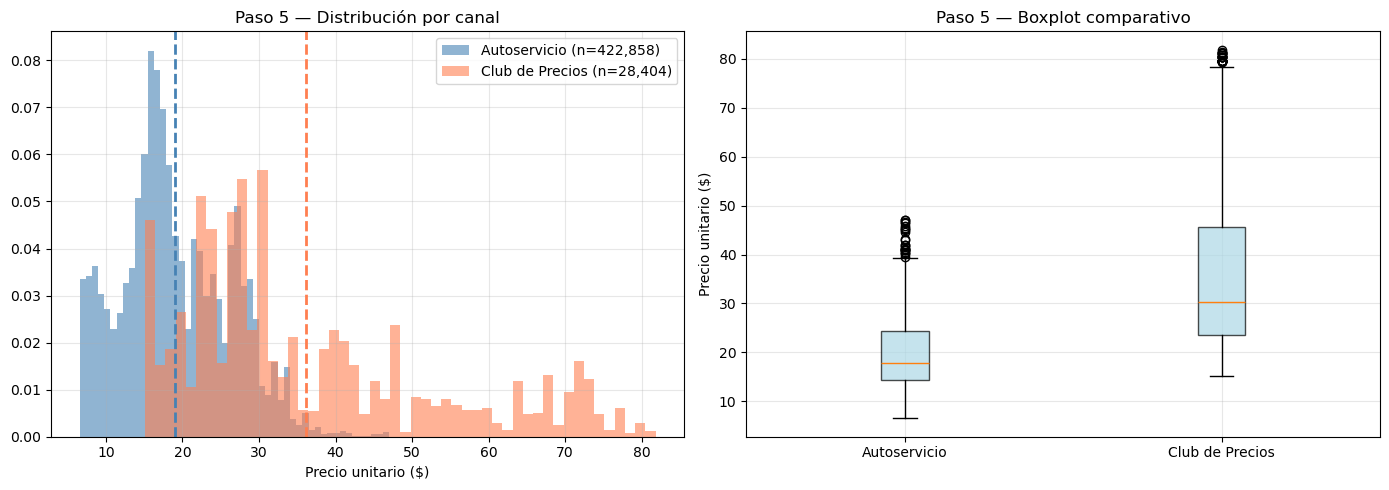

In [3]:
# ============================================================
# S4.6 — PASO 1 A 5: PREPARACIÓN Y EXPLORACIÓN
# ============================================================

# Paso 1 — Pregunta de negocio:
# ¿El precio unitario promedio difiere entre Autoservicio y Club de Precios?

# Paso 2 — Hipótesis:
# H₀: μ_autoservicio = μ_club  (no hay diferencia real)
# H₁: μ_autoservicio ≠ μ_club  (sí hay diferencia real)

# Paso 3 — Nivel de significancia
alpha = 0.05

# Paso 4 — Preparar grupos
df['precio_unitario'] = df['Costo_Venta'] / df['Piezas_Entregadas'].replace(0, np.nan)

autoservicio = df[df['Canal1'] == 'Autoservicio']['precio_unitario'].dropna()
club         = df[df['Canal1'] == 'Club de Precios']['precio_unitario'].dropna()

# Filtrar outliers extremos (percentil 1-99)
autoservicio = autoservicio[
    (autoservicio >= autoservicio.quantile(0.01)) &
    (autoservicio <= autoservicio.quantile(0.99))
]
club = club[
    (club >= club.quantile(0.01)) &
    (club <= club.quantile(0.99))
]

print("=== PASO 4 — DESCRIPCIÓN DE GRUPOS ===")
print(f"Autoservicio:    n={len(autoservicio):,}  media=${autoservicio.mean():.2f}  std=${autoservicio.std():.2f}")
print(f"Club de Precios: n={len(club):,}  media=${club.mean():.2f}  std=${club.std():.2f}")
print(f"\nDiferencia observada: ${abs(autoservicio.mean() - club.mean()):.2f}")

# Paso 5 — Exploración visual
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogramas
ax = axes[0]
ax.hist(autoservicio.sample(5000, random_state=42), bins=50,
        alpha=0.6, color='steelblue', label=f'Autoservicio (n={len(autoservicio):,})', density=True)
ax.hist(club.sample(min(5000, len(club)), random_state=42), bins=50,
        alpha=0.6, color='coral', label=f'Club de Precios (n={len(club):,})', density=True)
ax.axvline(autoservicio.mean(), color='steelblue', linestyle='--', linewidth=2)
ax.axvline(club.mean(), color='coral', linestyle='--', linewidth=2)
ax.set_xlabel('Precio unitario ($)')
ax.set_title('Paso 5 — Distribución por canal')
ax.legend()

# Boxplot
ax = axes[1]
ax.boxplot([autoservicio.sample(5000, random_state=42),
            club.sample(min(5000, len(club)), random_state=42)],
           labels=['Autoservicio', 'Club de Precios'],
           patch_artist=True,
           boxprops=dict(facecolor='lightblue', alpha=0.7))
ax.set_ylabel('Precio unitario ($)')
ax.set_title('Paso 5 — Boxplot comparativo')

plt.tight_layout()
plt.savefig('../reports/S4.6_exploracion.png', dpi=150, bbox_inches='tight')
plt.show()

In [4]:
# ============================================================
# S4.6 — PASOS 6 A 11: T-TEST Y CONCLUSIÓN
# ============================================================

# Paso 6 y 7 — Calcular estadístico t y p-value
# Usamos Welch's t-test (equal_var=False) porque las varianzas
# son diferentes (std=$7 vs std=$16)

t_stat, p_value = stats.ttest_ind(autoservicio, club, equal_var=False)

print("=== PASOS 6-7: RESULTADO DEL T-TEST ===")
print(f"Estadístico t: {t_stat:.4f}")
print(f"P-value:       {p_value:.2e}")
print(f"Alpha:         {alpha}")

# Paso 8 — Decisión
print(f"\n=== PASO 8: DECISIÓN ===")
if p_value < alpha:
    print(f"p={p_value:.2e} < α={alpha} → RECHAZAMOS H₀")
    print("Hay evidencia estadística de diferencia real entre canales")
else:
    print(f"p={p_value:.2e} ≥ α={alpha} → NO rechazamos H₀")
    print("No hay evidencia suficiente de diferencia")

# Paso 9 — Tamaño del efecto (Cohen's d)
# Mide QUÉ TAN GRANDE es la diferencia, no solo si existe
# d < 0.2 = pequeño, 0.2-0.5 = mediano, > 0.8 = grande
pooled_std = np.sqrt((autoservicio.std()**2 + club.std()**2) / 2)
cohens_d   = (club.mean() - autoservicio.mean()) / pooled_std
print(f"\n=== PASO 9: TAMAÑO DEL EFECTO ===")
print(f"Cohen's d: {cohens_d:.3f}")
if abs(cohens_d) < 0.2:
    efecto = "pequeño"
elif abs(cohens_d) < 0.5:
    efecto = "mediano"
elif abs(cohens_d) < 0.8:
    efecto = "grande"
else:
    efecto = "muy grande"
print(f"Tamaño del efecto: {efecto}")

# Pasos 10-11 — Traducción a negocio
print(f"\n=== PASOS 10-11: TRADUCCIÓN A NEGOCIO ===")
print(f"Autoservicio:    ${autoservicio.mean():.2f} promedio por pieza")
print(f"Club de Precios: ${club.mean():.2f} promedio por pieza")
print(f"Diferencia:      ${club.mean()-autoservicio.mean():.2f} (+{(club.mean()/autoservicio.mean()-1)*100:.1f}%)")
print(f"\nMensaje al gerente:")
print(f"'El precio unitario en Club de Precios es {(club.mean()/autoservicio.mean()-1)*100:.0f}% mayor")
print(f"que en Autoservicio (${club.mean():.2f} vs ${autoservicio.mean():.2f}).")
print(f"Esta diferencia es estadísticamente significativa (p<0.001)")
print(f"con un efecto {efecto} (d={cohens_d:.2f}).'")

=== PASOS 6-7: RESULTADO DEL T-TEST ===
Estadístico t: -171.3098
P-value:       0.00e+00
Alpha:         0.05

=== PASO 8: DECISIÓN ===
p=0.00e+00 < α=0.05 → RECHAZAMOS H₀
Hay evidencia estadística de diferencia real entre canales

=== PASO 9: TAMAÑO DEL EFECTO ===
Cohen's d: 1.330
Tamaño del efecto: muy grande

=== PASOS 10-11: TRADUCCIÓN A NEGOCIO ===
Autoservicio:    $19.06 promedio por pieza
Club de Precios: $36.09 promedio por pieza
Diferencia:      $17.03 (+89.4%)

Mensaje al gerente:
'El precio unitario en Club de Precios es 89% mayor
que en Autoservicio ($36.09 vs $19.06).
Esta diferencia es estadísticamente significativa (p<0.001)
con un efecto muy grande (d=1.33).'


=== ERRORES EN TEST DE HIPÓTESIS ===

              │  H₀ es VERDADERA  │  H₀ es FALSA
──────────────┼───────────────────┼──────────────────
No rechazar   │  ✅ Decisión OK   │  ❌ Error Tipo II
Rechazar H₀   │  ❌ Error Tipo I  │  ✅ Decisión OK

Error Tipo I  (α): Rechazar H₀ cuando es verdadera → Falsa alarma
Error Tipo II (β): No rechazar H₀ cuando es falsa  → Oportunidad perdida



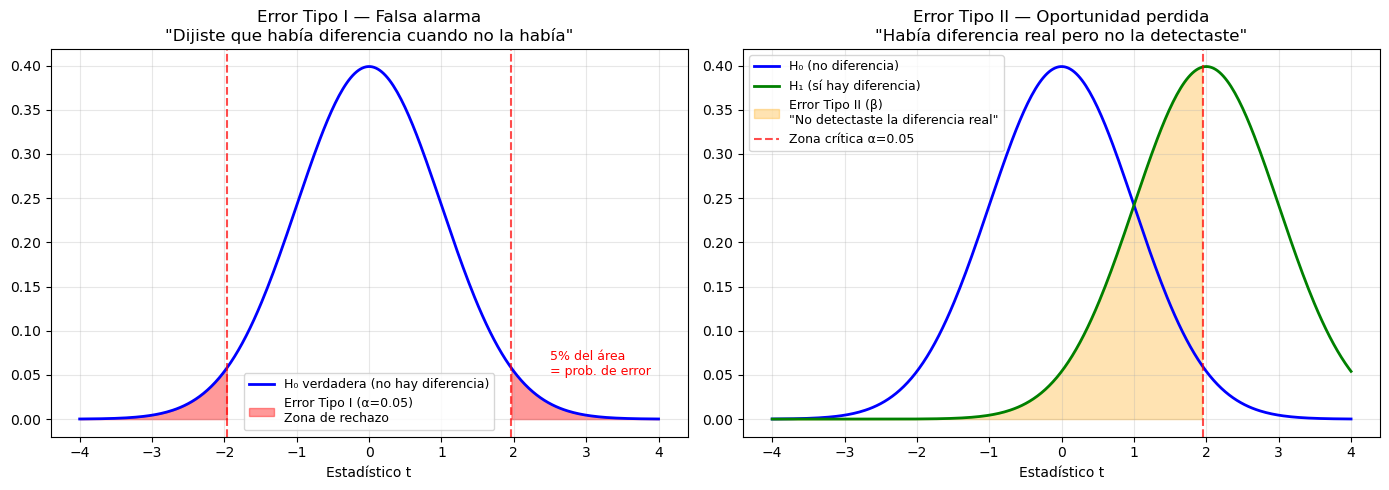

=== EJEMPLOS EN NEGOCIO RETAIL ===

Error Tipo I (α) — Falsa alarma:
  Lanzas una promoción porque el test dice que aumentó ventas,
  pero en realidad fue variación aleatoria. Gastas presupuesto innecesariamente.

Error Tipo II (β) — Oportunidad perdida:
  El test dice que no hay diferencia entre dos precios,
  pero sí la había — simplemente tu muestra era muy pequeña.
  No ajustas el precio y pierdes margen.

Trade-off: reducir α aumenta β y viceversa.
Por eso α=0.05 es el balance estándar en la mayoría de casos.


In [5]:
# ============================================================
# S4.6 — ERROR TIPO I Y TIPO II
# ============================================================

print("=== ERRORES EN TEST DE HIPÓTESIS ===")
print()
print("              │  H₀ es VERDADERA  │  H₀ es FALSA")
print("──────────────┼───────────────────┼──────────────────")
print("No rechazar   │  ✅ Decisión OK   │  ❌ Error Tipo II")
print("Rechazar H₀   │  ❌ Error Tipo I  │  ✅ Decisión OK")
print()
print("Error Tipo I  (α): Rechazar H₀ cuando es verdadera → Falsa alarma")
print("Error Tipo II (β): No rechazar H₀ cuando es falsa  → Oportunidad perdida")
print()

# Simulación visual — demostrar los errores
np.random.seed(42)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Error Tipo I: α = probabilidad de falsa alarma ---
ax = axes[0]
x = np.linspace(-4, 4, 300)
pdf = stats.norm.pdf(x, 0, 1)

ax.plot(x, pdf, 'b-', linewidth=2, label='H₀ verdadera (no hay diferencia)')
ax.fill_between(x, pdf, where=(x >= 1.96), alpha=0.4, color='red',
                label=f'Error Tipo I (α=0.05)\nZona de rechazo')
ax.fill_between(x, pdf, where=(x <= -1.96), alpha=0.4, color='red')
ax.axvline(1.96, color='red', linestyle='--', alpha=0.7)
ax.axvline(-1.96, color='red', linestyle='--', alpha=0.7)
ax.set_title('Error Tipo I — Falsa alarma\n"Dijiste que había diferencia cuando no la había"')
ax.set_xlabel('Estadístico t')
ax.legend(fontsize=9)
ax.annotate('5% del área\n= prob. de error', xy=(2.5, 0.05),
            fontsize=9, color='red')

# --- Error Tipo II: β = oportunidad perdida ---
ax = axes[1]
mu_h0, mu_h1 = 0, 2   # H₀ y H₁ separadas por 2 unidades
pdf_h0 = stats.norm.pdf(x, mu_h0, 1)
pdf_h1 = stats.norm.pdf(x, mu_h1, 1)

ax.plot(x, pdf_h0, 'b-', linewidth=2, label='H₀ (no diferencia)')
ax.plot(x, pdf_h1, 'g-', linewidth=2, label='H₁ (sí hay diferencia)')
ax.fill_between(x, pdf_h1, where=(x <= 1.96), alpha=0.3, color='orange',
                label='Error Tipo II (β)\n"No detectaste la diferencia real"')
ax.axvline(1.96, color='red', linestyle='--', alpha=0.7, label='Zona crítica α=0.05')
ax.set_title('Error Tipo II — Oportunidad perdida\n"Había diferencia real pero no la detectaste"')
ax.set_xlabel('Estadístico t')
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('../reports/S4.6_errores_tipo.png', dpi=150, bbox_inches='tight')
plt.show()

# Ejemplos de negocio
print("=== EJEMPLOS EN NEGOCIO RETAIL ===")
print()
print("Error Tipo I (α) — Falsa alarma:")
print("  Lanzas una promoción porque el test dice que aumentó ventas,")
print("  pero en realidad fue variación aleatoria. Gastas presupuesto innecesariamente.")
print()
print("Error Tipo II (β) — Oportunidad perdida:")
print("  El test dice que no hay diferencia entre dos precios,")
print("  pero sí la había — simplemente tu muestra era muy pequeña.")
print("  No ajustas el precio y pierdes margen.")
print()
print("Trade-off: reducir α aumenta β y viceversa.")
print("Por eso α=0.05 es el balance estándar en la mayoría de casos.")

In [6]:
# ============================================================
# S4.6 — SEGUNDA HIPÓTESIS: WALMART VS SORIANA
# ============================================================

# Pregunta: ¿El precio unitario difiere entre Walmart y Soriana?
# H₀: μ_walmart = μ_soriana
# H₁: μ_walmart ≠ μ_soriana

walmart = df[df['Canal2'] == 'Walmart']['precio_unitario'].dropna()
soriana = df[df['Canal2'] == 'Soriana']['precio_unitario'].dropna()

# Filtrar outliers
for nombre, grupo in [('walmart', walmart), ('soriana', soriana)]:
    mask = (grupo >= grupo.quantile(0.01)) & (grupo <= grupo.quantile(0.99))
    if nombre == 'walmart':
        walmart = grupo[mask]
    else:
        soriana = grupo[mask]

# T-test
t_stat2, p_value2 = stats.ttest_ind(walmart, soriana, equal_var=False)
pooled_std2 = np.sqrt((walmart.std()**2 + soriana.std()**2) / 2)
cohens_d2   = (soriana.mean() - walmart.mean()) / pooled_std2

print("=== WALMART VS SORIANA ===")
print(f"Walmart: n={len(walmart):,}  media=${walmart.mean():.2f}  std=${walmart.std():.2f}")
print(f"Soriana: n={len(soriana):,}  media=${soriana.mean():.2f}  std=${soriana.std():.2f}")
print(f"\nt={t_stat2:.4f}  p={p_value2:.2e}  Cohen's d={cohens_d2:.3f}")
print(f"\nDiferencia: ${abs(walmart.mean()-soriana.mean()):.2f}")

if p_value2 < 0.05:
    print(f"\n→ RECHAZAMOS H₀: hay diferencia real")
else:
    print(f"\n→ NO rechazamos H₀: no hay evidencia de diferencia")

if abs(cohens_d2) < 0.2:
    print(f"→ Efecto PEQUEÑO — diferencia estadística pero no práctica")
elif abs(cohens_d2) < 0.5:
    print(f"→ Efecto MEDIANO")
else:
    print(f"→ Efecto GRANDE")

=== WALMART VS SORIANA ===
Walmart: n=149,699  media=$17.35  std=$7.26
Soriana: n=101,894  media=$20.06  std=$7.26

t=-91.7580  p=0.00e+00  Cohen's d=0.373

Diferencia: $2.70

→ RECHAZAMOS H₀: hay diferencia real
→ Efecto MEDIANO
